# Clusters of Galaxies DEMO

> An executed version of this notebook can be found [here](https://me.lsst.eu/maguena/euclid/cloecl/DEMO_Clusters_of_Galaxies.html)
> (user:cloecl, pwd:cluster)

Download the validation tables here: https://zenodo.org/records/15914129

# Table of Contents

* [Galaxy Cluster Observables](#chapt1)
    * [Halo Mass Function](#chapt1_1)
    * [Excess Surface Density](#chapt1_2)
        * [Centered profiles](#chapt1_2_1)
        * [Off-centered profiles](#chapt1_2_2)
    * [2-point correlation function](#chapt1_3)
* [Galaxy Cluster Summary Statistics](#chapt2)
    * [Number Counts](#chapt2_1)
    * [Reduced Shear Profiles](#chapt2_2)
    * [2-point correlation function](#chapt2_3)

## Import necessary packages and set directories <a class="anchor" id="sec0.1"></a>

In [1]:
# General Python imports
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations
from cloelib.observables.clusters.halo_abundance import CastroHaloAbundance
from cloelib.observables.clusters.halo_clustering import TwoPoint3DHaloClustering
from cloelib.observables.clusters.covariance import HaloCovariance
from cloelib.observables.clusters.matter_statistics import MatterStatistics
from cloelib.observables.clusters.halo_profile import BMOHaloProfile, NFWHaloProfile
from cloelib.observables.clusters.selection_function import GaussianSelectionFunction
from cloelib.observables.clusters.halo_mass_observable import (
    LognormalPowerLawHaloMassObservable,
)
from cloelib.observables.clusters.halo_abundance import TinkerHaloAbundance

# CLOE imports


%matplotlib inline

In [2]:
# Set the path for the validation tables, it murt contain the subdirectories: HMF_validation_tables, DeltaSigma_validation_tables
# root_dir = "/sps/euclid/OU-LE3/CL/CLOE/validation_tables/data/clusters/"  # for cc-in2p3
root_dir = "../../data/clusters/"  # for local data

# subdirectories, should all be inside the forder provided
valid_tables_dir = os.path.join(root_dir, "validation_tables")
DeltaSigma_dir = os.path.join(valid_tables_dir, "DeltaSigma_validation_tables")
hmf_root_dir = os.path.join(valid_tables_dir, "HMF_validation_tables")
Pk_dir = os.path.join(hmf_root_dir, "Pk-C0")

truth_tables_dir = os.path.join(root_dir, "truth_tables")
nc_dir = os.path.join(truth_tables_dir, "numbercounts_truth_tables")
clustering_dir = os.path.join(truth_tables_dir, "clustering_truth_tables")

# Galaxy Cluster Observables <a class="anchor" id="chapt1"></a>

In [3]:
# Instanciate cosmology
# Cosmology parameters
cosmo_parameters = dict(
    H0=67.321,
    Omega_cdm0=0.264979,
    Omega_b0=0.0494,
    Omega_k0=0.0,
    w0=-1.0,
    wa=0.0,
    ns=0.9661,
    mnu=0.06,
    As=2.09175e-9,
    gamma_MG=0.0,
    N_mnu=1,
    N_ur=2.046,
)

background = CAMBBackground(**cosmo_parameters)
background_fid = CAMBBackground(**cosmo_parameters)

start = time.time()
perturbations = CAMBLinearPerturbations(background, np.linspace(0.0, 2.0, 100))
end = time.time()
print(f"⏱️ Time elapsed: {end - start:.3f} seconds")

print(f"\nsigma8 in the code: {perturbations.sigma8_0()}")
print(f"sigma8 in the Castro+ validation tables: {0.8102}")

Note: redshifts have been re-sorted (earliest first)
⏱️ Time elapsed: 7.842 seconds

sigma8 in the code: 0.8091000608178137
sigma8 in the Castro+ validation tables: 0.8102


In [4]:
# arrays for interpolation
k = np.geomspace(1e-4, 10, 500)
zed = np.linspace(1.0e-5, 6.0 - 1.0e-5, 200)

## Dark Matter Statistics <a class="anchor" id="chapt0_1"></a>
Main object that handles basic statistical functions like interpolating the power spectrum and computing DM correlation

In [5]:
matter_stat = MatterStatistics(perturbations, z=zed, k=k)

## Halo Mass Function <a class="anchor" id="chapt1_1"></a>

In [6]:
HSCastro = CastroHaloAbundance(matter_stat)
HSTinker = TinkerHaloAbundance(matter_stat, overdensity_type="vir")

In [7]:
area = 10313
covariance = HaloCovariance(perturbations, area=area, nbins_zob=9, k=k, z_tab_integ=31)

In [8]:
# Set the file names for the validation tables
filename = [
    "truth-table-Piccolo-00-z0.0.txt",
    "truth-table-Piccolo-00-z0.2137248000388392.txt",
    "truth-table-Piccolo-00-z0.42515106601299735.txt",
    "truth-table-Piccolo-00-z0.673416111650323.txt",
    "truth-table-Piccolo-00-z0.9649067651739924.txt",
    "truth-table-Piccolo-00-z1.7090726844201227.txt",
]
# Declare the redshift array
zed_test = np.array(
    [
        0.0000,
        0.2137248000388392,
        0.42515106601299735,
        0.673416111650323,
        0.9649067651739924,
        1.7090726844201227,
    ]
)

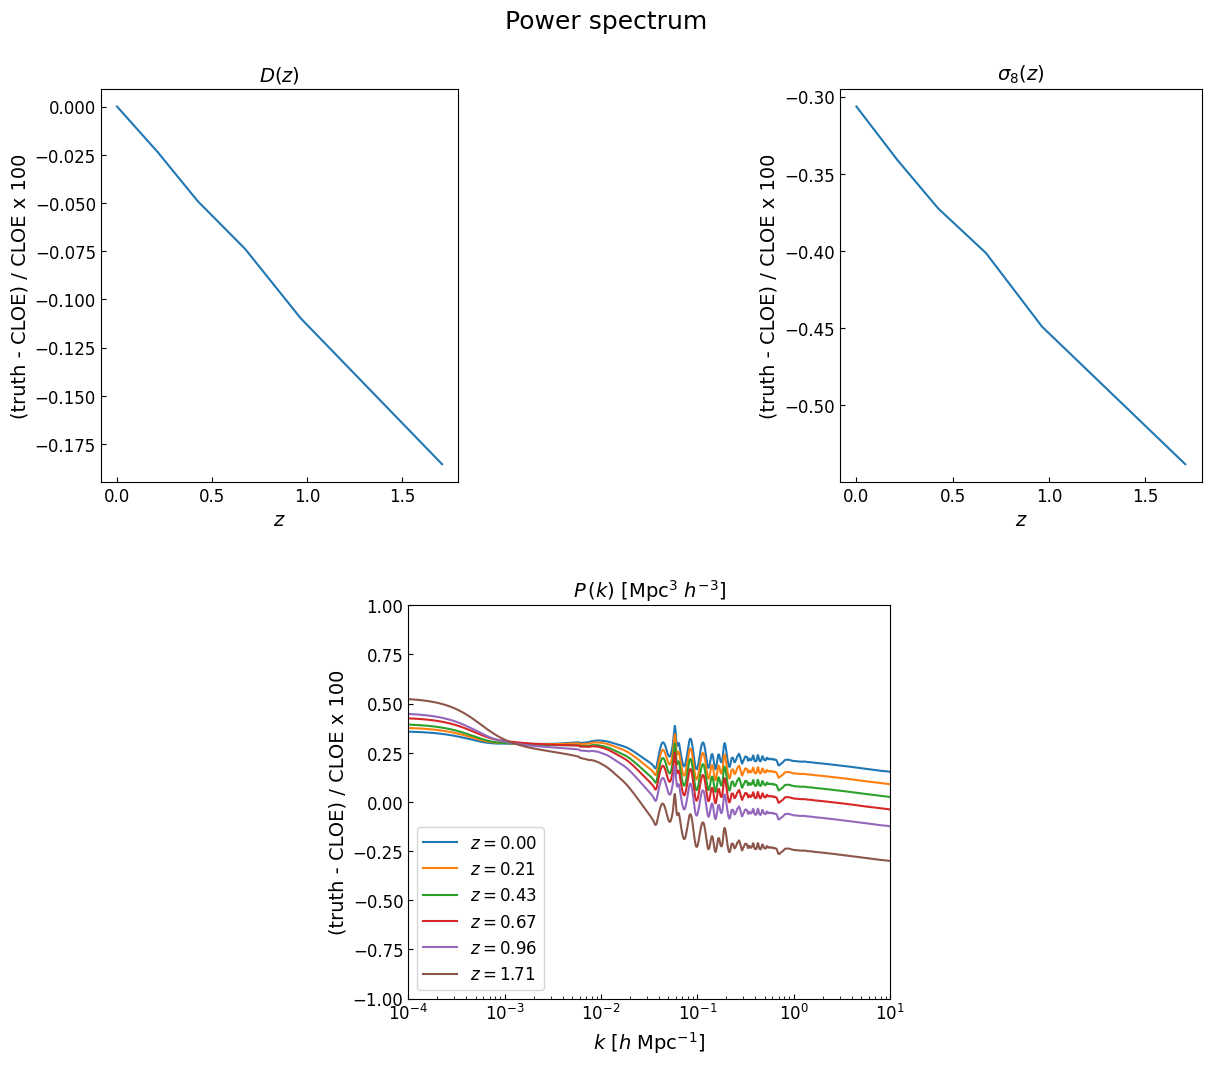

In [9]:
def plot_intermediate_products(zed):
    # Declare the true OmegaM(z), D(z), sigma8(z) arrays
    OmegaM_true = np.array(
        [
            3.158000e-01,
            4.521322e-01,
            5.719208e-01,
            6.838367e-01,
            7.778521e-01,
            9.017372e-01,
        ]
    )
    Dz_true = np.array(
        [1.0, 8.925343e-01, 7.987282e-01, 7.052811e-01, 6.159577e-01, 4.594538e-01]
    )
    sigma8_true = np.array([0.8102, 0.7231, 0.6471, 0.5714, 0.4990, 0.3722])

    # Set the Pk file name
    Pk_fileroot = "Pk-PICCOLO-C0-z"
    Pk_filename = ["0.0000", "0.2137", "0.4252", "0.6734", "0.9649", "1.7091"]

    # HMF validation
    fig = plt.figure(constrained_layout=True, figsize=(12, 10))
    gs = fig.add_gridspec(
        3, 5, width_ratios=[2, 0.5, 1.5, 0.5, 2], height_ratios=[1, 0.1, 1]
    )

    fig.suptitle("Power spectrum", fontsize=18, y=1.05)

    # D(z)
    ax1 = fig.add_subplot(gs[0, 0:2])
    ax1.xaxis.set_tick_params(direction="in", which="both", labelsize=12)
    ax1.yaxis.set_tick_params(direction="in", which="both", labelsize=12)
    ax1.set_xlabel(r"$z$", color="black", fontsize=14)
    ax1.set_ylabel("(truth - CLOE) / CLOE x 100", color="black", fontsize=14)
    ax1.set_title(r"$D(z)$", fontsize=14)

    Dz_theo = perturbations.growth_factor(zed, 0.05)
    ax1.plot(zed, (Dz_true - Dz_theo) / Dz_theo * 100.0)

    # sigma8(z)
    ax2 = fig.add_subplot(gs[0, 3:5])
    ax2.xaxis.set_tick_params(direction="in", which="both", labelsize=12)
    ax2.yaxis.set_tick_params(direction="in", which="both", labelsize=12)
    ax2.set_xlabel(r"$z$", color="black", fontsize=14)
    ax2.set_ylabel("(truth - CLOE) / CLOE x 100", color="black", fontsize=14)
    ax2.set_title(r"$\sigma_8(z)$", fontsize=14)

    sigma8_theo = HSTinker.core.sigma_z_R(zed, np.full(zed.shape, 8.0)).T[0]

    ax2.plot(zed, (sigma8_true - sigma8_theo) / sigma8_theo * 100.0)

    # Pk
    ax4 = fig.add_subplot(gs[2, 1:4])
    ax4.xaxis.set_tick_params(direction="in", which="both", labelsize=12)
    ax4.yaxis.set_tick_params(direction="in", which="both", labelsize=12)
    ax4.set_xscale("log")
    ax4.set_xlabel(r"$k$ [$h$ Mpc$^{-1}$]", color="black", fontsize=14)
    ax4.set_ylabel("(truth - CLOE) / CLOE x 100", color="black", fontsize=14)
    ax4.set_title(r"$P\,(k)$ [Mpc$^3$ $h^{-3}$]", fontsize=14)

    for i in range(len(Pk_filename)):
        k = np.genfromtxt(
            os.path.join(Pk_dir, Pk_fileroot + Pk_filename[i] + ".txt"),
            usecols=(0),
            dtype=None,
            skip_header=2,
        )
        Pk_true = np.genfromtxt(
            os.path.join(Pk_dir, Pk_fileroot + Pk_filename[i] + ".txt"),
            usecols=(1),
            dtype=None,
            skip_header=2,
        )

        Pk_theo = perturbations.matter_power_spectrum(
            zed[i], k, hubble_units=True, k_hunit=True
        )

        ax4.plot(
            k,
            (Pk_true - Pk_theo) / Pk_theo * 100.0,
            label=r"$z=$" + str("{:.2f}".format(zed[i])),
        )

    ax4.legend(loc="lower left", prop={"size": 12})
    ax4.set_xlim([1.0e-4, 10.0])
    ax4.set_ylim([-1.0, 1.0])
    plt.show()


plot_intermediate_products(zed_test)

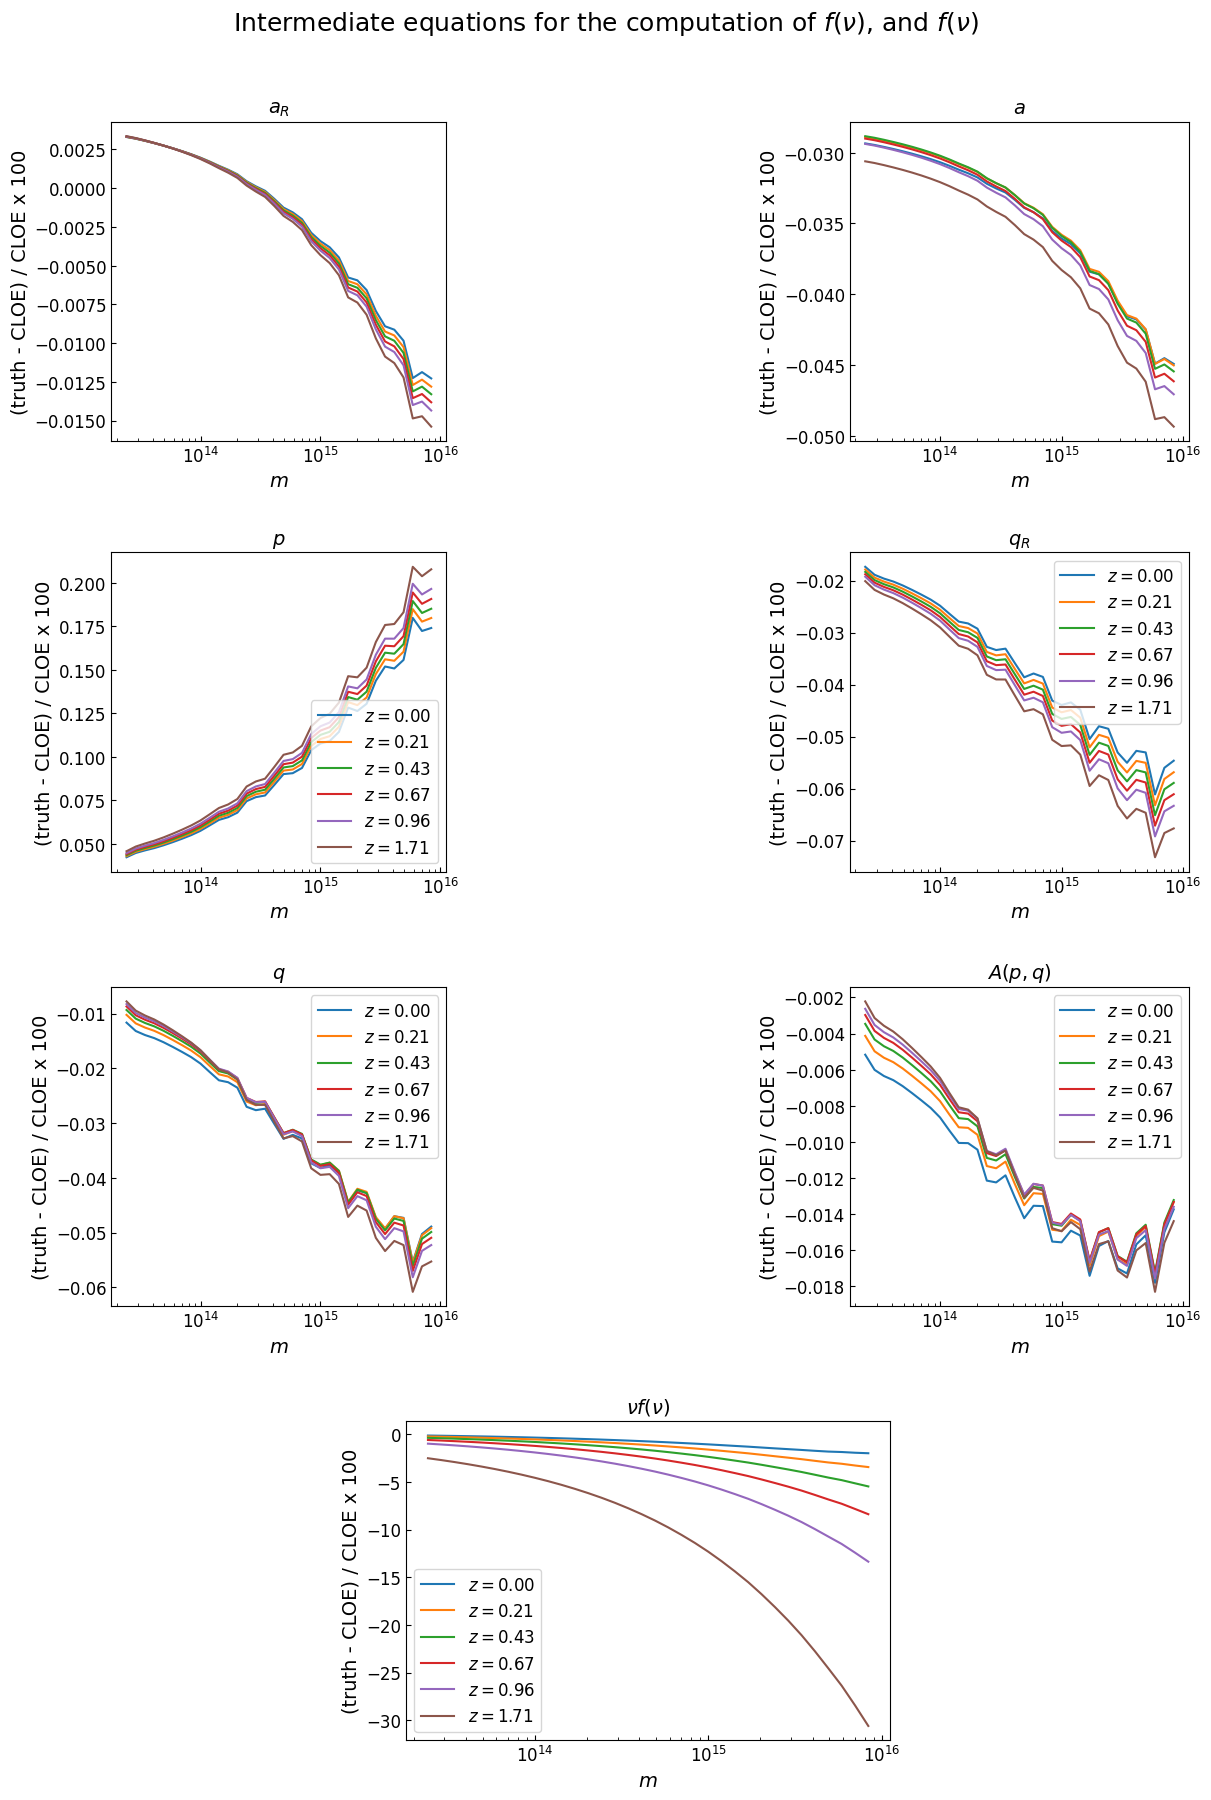

In [10]:
from scipy.special import gamma


def plot_hmf_valid(zed):
    # -----------------------------
    # Define the HMF parameters

    a1 = 0.7962
    a2 = 0.1449
    az = -0.0658
    p1 = -0.5612
    p2 = -0.4743
    q1 = 0.3688
    q2 = -0.2804
    qz = 0.0251

    # -----------------------------
    # Compute and plot

    fig = plt.figure(constrained_layout=True, figsize=(12, 17))
    gs = fig.add_gridspec(
        7,
        5,
        width_ratios=[2, 0.5, 1.5, 0.5, 2],
        height_ratios=[1, 0.1, 1, 0.1, 1, 0.1, 1],
    )

    fig.suptitle(
        "Intermediate equations for the computation of "
        + r"$f(\nu)$"
        + ", and "
        + r"$f(\nu)$",
        fontsize=18,
        y=1.05,
    )

    # aR
    ax0 = fig.add_subplot(gs[0, 0:2])
    ax0.xaxis.set_tick_params(direction="in", which="both", labelsize=12)
    ax0.yaxis.set_tick_params(direction="in", which="both", labelsize=12)
    ax0.set_xscale("log")
    ax0.set_xlabel(r"$m$", color="black", fontsize=14)
    ax0.set_ylabel("(truth - CLOE) / CLOE x 100", color="black", fontsize=14)
    ax0.set_title(r"$a_R$", fontsize=14)

    # a
    ax02 = fig.add_subplot(gs[0, 3:5])
    ax02.xaxis.set_tick_params(direction="in", which="both", labelsize=12)
    ax02.yaxis.set_tick_params(direction="in", which="both", labelsize=12)
    ax02.set_xscale("log")
    ax02.set_xlabel(r"$m$", color="black", fontsize=14)
    ax02.set_ylabel("(truth - CLOE) / CLOE x 100", color="black", fontsize=14)
    ax02.set_title(r"$a$", fontsize=14)

    # p
    ax1 = fig.add_subplot(gs[2, 0:2])
    ax1.xaxis.set_tick_params(direction="in", which="both", labelsize=12)
    ax1.yaxis.set_tick_params(direction="in", which="both", labelsize=12)
    ax1.set_xscale("log")
    ax1.set_xlabel(r"$m$", color="black", fontsize=14)
    ax1.set_ylabel("(truth - CLOE) / CLOE x 100", color="black", fontsize=14)
    ax1.set_title(r"$p$", fontsize=14)

    # qR
    ax2 = fig.add_subplot(gs[2, 3:5])
    ax2.xaxis.set_tick_params(direction="in", which="both", labelsize=12)
    ax2.yaxis.set_tick_params(direction="in", which="both", labelsize=12)
    ax2.set_xscale("log")
    ax2.set_xlabel(r"$m$", color="black", fontsize=14)
    ax2.set_ylabel("(truth - CLOE) / CLOE x 100", color="black", fontsize=14)
    ax2.set_title(r"$q_R$", fontsize=14)

    # q
    ax3 = fig.add_subplot(gs[4, 0:2])
    ax3.xaxis.set_tick_params(direction="in", which="both", labelsize=12)
    ax3.yaxis.set_tick_params(direction="in", which="both", labelsize=12)
    ax3.set_xscale("log")
    ax3.set_xlabel(r"$m$", color="black", fontsize=14)
    ax3.set_ylabel("(truth - CLOE) / CLOE x 100", color="black", fontsize=14)
    ax3.set_title(r"$q$", fontsize=14)

    # A
    ax4 = fig.add_subplot(gs[4, 3:5])  # (gs[4,1:4])
    ax4.xaxis.set_tick_params(direction="in", which="both", labelsize=12)
    ax4.yaxis.set_tick_params(direction="in", which="both", labelsize=12)
    ax4.set_xscale("log")
    ax4.set_xlabel(r"$m$", color="black", fontsize=14)
    ax4.set_ylabel("(truth - CLOE) / CLOE x 100", color="black", fontsize=14)
    ax4.set_title(r"$A(p,q)$", fontsize=14)

    # f(nu)
    ax5 = fig.add_subplot(gs[6, 1:4])
    ax5.xaxis.set_tick_params(direction="in", which="both", labelsize=12)
    ax5.yaxis.set_tick_params(direction="in", which="both", labelsize=12)
    ax5.set_xscale("log")
    ax5.set_xlabel(r"$m$", color="black", fontsize=14)
    ax5.set_ylabel("(truth - CLOE) / CLOE x 100", color="black", fontsize=14)
    ax5.set_title(r"$\nu f(\nu)$", fontsize=14)

    for i in range(len(filename)):
        mass = np.genfromtxt(
            os.path.join(hmf_root_dir, filename[i]),
            usecols=(0),
            dtype=None,
            skip_header=2,
        )
        aR_true = np.genfromtxt(
            os.path.join(hmf_root_dir, filename[i]),
            usecols=(5),
            dtype=None,
            skip_header=2,
        )
        aR_theo = (
            a1
            + a2
            * (3 * HSCastro.core.dlns_dlnM(zed[i : i + 1], mass)[0] + 0.6125) ** 2.0
        )

        # aR
        ax0.plot(
            mass,
            (aR_true - aR_theo) / aR_theo * 100.0,
            label=r"$z=$" + str("{:.2f}".format(zed[i])),
        )

        # a
        a_true = np.genfromtxt(
            os.path.join(hmf_root_dir, filename[i]),
            usecols=(6),
            dtype=None,
            skip_header=2,
        )
        a_theo = aR_theo * background.Omega_cb(zed[i]) ** az
        ax02.plot(
            mass,
            (a_true - a_theo) / a_theo * 100.0,
            label=r"$z=$" + str("{:.2f}".format(zed[i])),
        )

        # p
        p_true = np.genfromtxt(
            os.path.join(hmf_root_dir, filename[i]),
            usecols=(7),
            dtype=None,
            skip_header=2,
        )
        p_theo = p1 + p2 * (3 * HSCastro.core.dlns_dlnM(zed[i : i + 1], mass)[0] + 0.5)

        ax1.plot(
            mass,
            (p_true - p_theo) / p_theo * 100.0,
            label=r"$z=$" + str("{:.2f}".format(zed[i])),
        )

        # qR
        qR_true = np.genfromtxt(
            os.path.join(hmf_root_dir, filename[i]),
            usecols=(8),
            dtype=None,
            skip_header=2,
        )
        qR_theo = q1 + q2 * (3 * HSCastro.core.dlns_dlnM(zed[i : i + 1], mass)[0] + 0.5)

        ax2.plot(
            mass,
            (qR_true - qR_theo) / qR_theo * 100.0,
            label=r"$z=$" + str("{:.2f}".format(zed[i])),
        )

        # q
        q_true = np.genfromtxt(
            os.path.join(hmf_root_dir, filename[i]),
            usecols=(9),
            dtype=None,
            skip_header=2,
        )
        q_theo = qR_theo * background.Omega_cb(zed[i]) ** qz

        ax3.plot(
            mass,
            (q_true - q_theo) / q_theo * 100.0,
            label=r"$z=$" + str("{:.2f}".format(zed[i])),
        )

        # A
        A_true = np.genfromtxt(
            os.path.join(hmf_root_dir, filename[i]),
            usecols=(4),
            dtype=None,
            skip_header=2,
        )

        p = p_theo
        q = q_theo
        A_theo = 1.0 / (
            2.0 ** (-0.5 - p + q / 2.0)
            / np.sqrt(np.pi)
            * (2.0**p * gamma(q / 2.0) + gamma(-p + q / 2.0))
        )

        ax4.plot(
            mass,
            (A_true - A_theo) / A_theo * 100.0,
            label=r"$z=$" + str("{:.2f}".format(zed[i])),
        )

        # f(nu)
        nufnu_true = np.genfromtxt(
            os.path.join(hmf_root_dir, filename[i]),
            usecols=(2),
            dtype=None,
            skip_header=2,
        )
        nufnu_theo = HSCastro.f_sigma_nu(np.array([zed[i]]), mass)[0]

        ax5.plot(
            mass,
            (nufnu_true - nufnu_theo) / nufnu_theo * 100.0,
            label=r"$z=$" + str("{:.2f}".format(zed[i])),
        )

    ax1.legend(loc="lower right", prop={"size": 12})
    ax2.legend(loc="upper right", prop={"size": 12})
    ax3.legend(loc="upper right", prop={"size": 12})
    ax4.legend(loc="upper right", prop={"size": 12})
    ax5.legend(loc="lower left", prop={"size": 12})

    plt.show()


plot_hmf_valid(zed_test)

## Excess Surface Density <a class="anchor" id="chapt1_2"></a>

Here we validate our functions computing the excess surface density ($\Delta\Sigma_+(R)$) by comparing their results with those obtained with COMB-CL, developed within OU-LE3, and with those obtained with CosmoBolognaLib (CBL; [Marulli+15](https://arxiv.org/abs/1511.00012)).

In [11]:
profile_parameters = dict(
    two_halo="None",
    zs_max=2.0,
    mean_nz=0.4,
    sigma_nz=0.3,
    alpha_nz=0.4,
)
halo_concentration = 0.1
profileNFW = NFWHaloProfile(matter_stat, z=zed, **profile_parameters)
profileBMO = BMOHaloProfile(matter_stat, z=zed, **profile_parameters)

In [12]:
# Set the fixed parameters
z = np.array([0.5])
conc = 4.0
mass = np.array([1e14 * background.h])

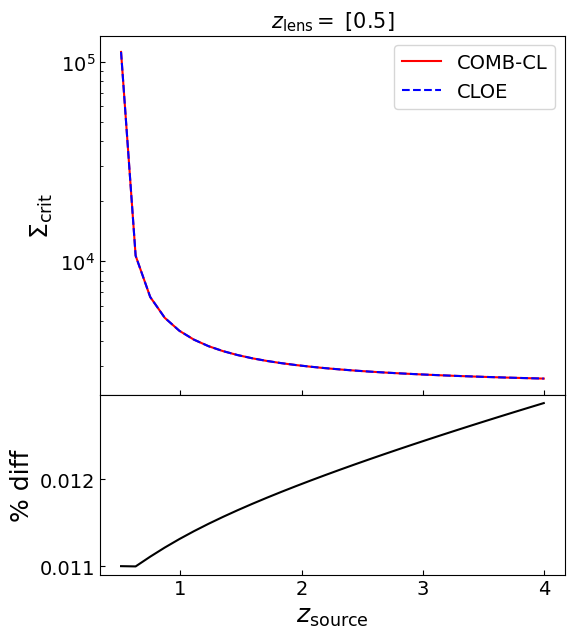

In [13]:
def plot_wl_valid():
    # Compute the quantities
    z_source = np.genfromtxt(
        os.path.join(DeltaSigma_dir, "Sigma_crit.txt"), usecols=(0), dtype=None
    )
    Sigma_crit_tr = (
        np.genfromtxt(
            os.path.join(DeltaSigma_dir, "Sigma_crit.txt"), usecols=(1), dtype=None
        )
        / background.h
    )
    Sigma_crit = profileNFW.core.sigma_crit(z, z_source)[0]

    # Plot
    fig, ax = plt.subplots(
        2, 1, figsize=(6, 7), gridspec_kw={"hspace": 0.0, "height_ratios": [1, 0.5]}
    )

    ax[0].set_yscale("log")
    for i in range(len(ax)):
        ax[i].xaxis.set_tick_params(direction="in", which="both", labelsize=14)
        ax[i].yaxis.set_tick_params(direction="in", which="both", labelsize=14)

    ax[1].set_xlabel(r"$z_{\rm source}$", fontsize=18)
    ax[0].set_ylabel(r"$\Sigma_{\rm crit}$", fontsize=18)
    ax[1].set_ylabel("% diff", fontsize=18)
    ax[0].set_title(r"$z_{\rm lens}=$ " + str(z), fontsize=15)

    ax[0].plot(z_source, Sigma_crit_tr, color="r", label="COMB-CL")
    ax[0].plot(z_source, Sigma_crit, "--", color="b", label="CLOE")

    ax[1].plot(z_source, (Sigma_crit - Sigma_crit_tr) / Sigma_crit_tr * 100, color="k")

    ax[0].legend(loc="upper right", fontsize=14)
    plt.show()


plot_wl_valid()

### Centered profiles <a class="anchor" id="chapt1_2_1"></a>

Now we validate the implementations of centered $\Sigma(R)$ and $\Delta\Sigma(R)$.\
But first, we show a nice plot of $\Delta\Sigma(R)$ given a NFW and a truncated NFW (BMO).

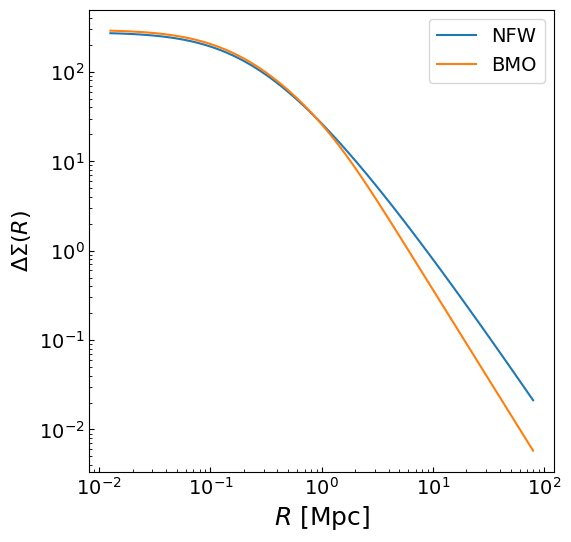

In [14]:
def centered_prof():
    # Compute
    r = np.logspace(-1.9, 1.9, 80)

    # matter_stat.overdensity = 200
    # HS.overdensity_type = "crit"
    DeltaSigma_NFW = profileNFW.excess_surface_mass_density(r, z, mass, conc)[0][0]
    DeltaSigma_BMO = profileBMO.excess_surface_mass_density(
        r,
        z,
        mass,
        conc,
    )[
        0
    ][0]

    # Plot
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.xaxis.set_tick_params(direction="in", which="both", labelsize=14)
    ax.yaxis.set_tick_params(direction="in", which="both", labelsize=14)
    ax.set_xlabel(r"$R$ [Mpc]", fontsize=18)
    ax.set_ylabel(r"$\Delta\Sigma(R)$", fontsize=16)
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.plot(r, DeltaSigma_NFW, label="NFW")
    ax.plot(r, DeltaSigma_BMO, label="BMO")

    ax.legend(loc="upper right", fontsize=14)
    plt.show()


centered_prof()

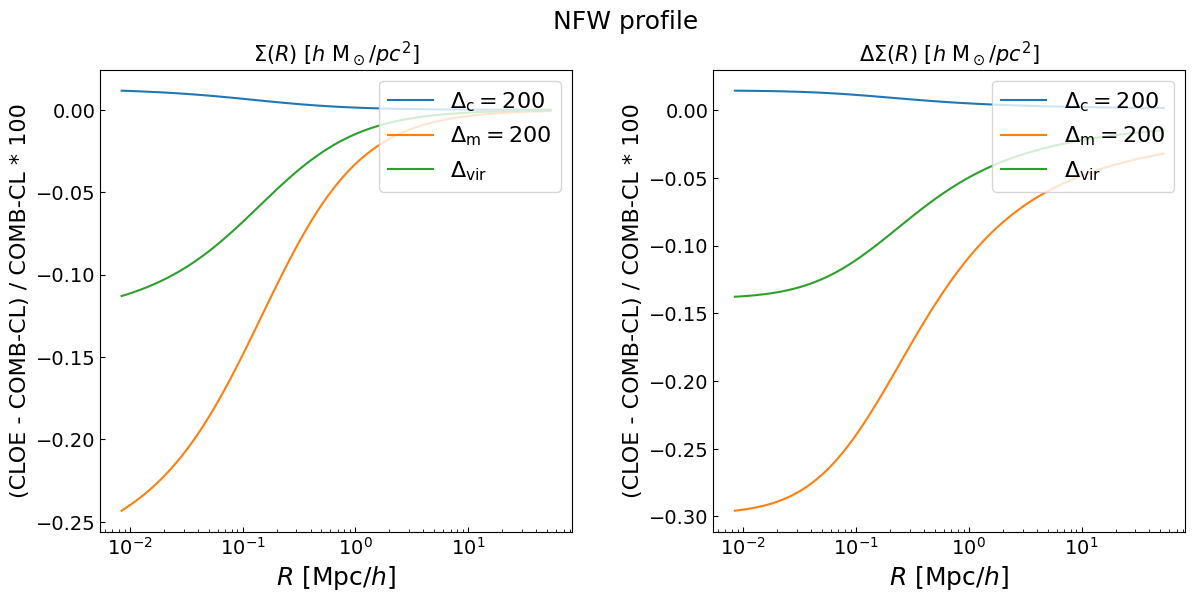

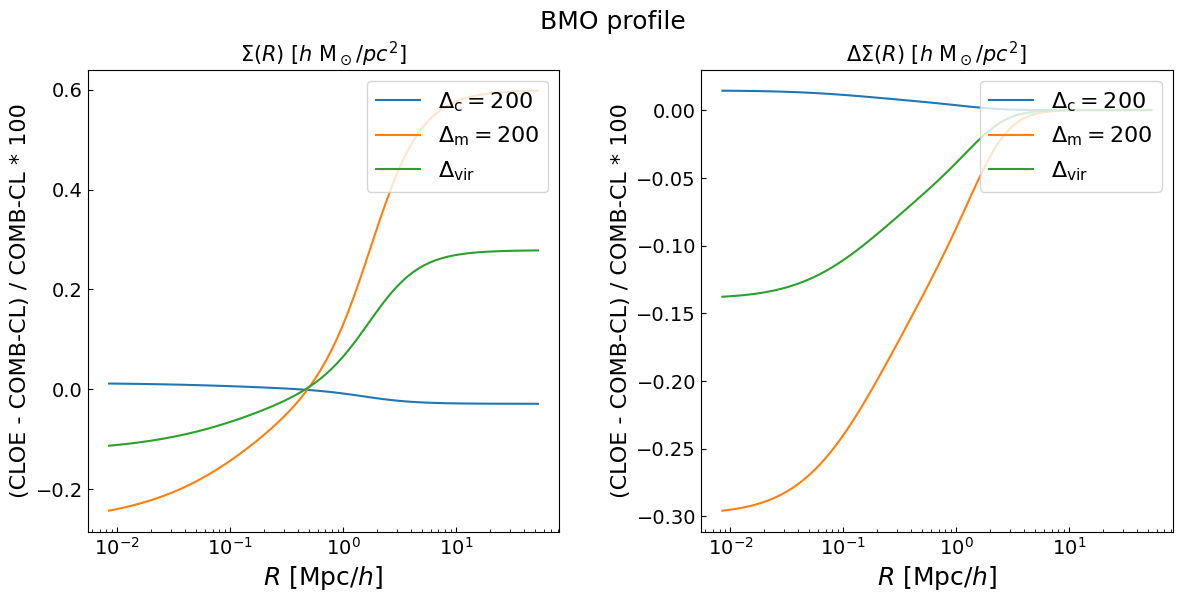

In [15]:
def validate_surface_profiles(profile, file_profile_suffix, title):

    if profile == "NFW":
        profiletype = profileNFW
    elif profile == "BMO":
        profiletype = profileBMO
    # HS.overdensity = 200

    # Compute Sigma
    file = "SigmaR_" + file_profile_suffix + ".txt"

    rad_S = (
        np.genfromtxt(os.path.join(DeltaSigma_dir, file), usecols=(0), dtype=None)
        * background.h
    )  # Mpc/h

    Sigma_200c_tr = (
        np.genfromtxt(os.path.join(DeltaSigma_dir, file), usecols=(1), dtype=None)
        / background.h
    )  # Ms pc^{-2} h
    Sigma_200m_tr = (
        np.genfromtxt(os.path.join(DeltaSigma_dir, file), usecols=(2), dtype=None)
        / background.h
    )  # Ms pc^{-2} h
    Sigma_vir_tr = (
        np.genfromtxt(os.path.join(DeltaSigma_dir, file), usecols=(3), dtype=None)
        / background.h
    )  # Ms pc^{-2} h

    profiletype.core.overdensity_type = "crit"
    Sigma_200c = profiletype.surface_mass_density(rad_S, z, mass, conc)[0][0]
    profiletype.core.overdensity_type = "mean"
    Sigma_200m = profiletype.surface_mass_density(rad_S, z, mass, conc)[0][0]
    profiletype.core.overdensity_type = "vir"
    Sigma_vir = profiletype.surface_mass_density(rad_S, z, mass, conc)[0][0]

    # Compute DeltaSigma
    file = "DeltaSigmaR_" + file_profile_suffix + ".txt"

    rad_DS = (
        np.genfromtxt(os.path.join(DeltaSigma_dir, file), usecols=(0), dtype=None)
        * background.h
    )  # Mpc/h

    DeltaSigma_200c_tr = (
        np.genfromtxt(os.path.join(DeltaSigma_dir, file), usecols=(1), dtype=None)
        / background.h
    )  # Ms pc^{-2} h
    DeltaSigma_200m_tr = (
        np.genfromtxt(os.path.join(DeltaSigma_dir, file), usecols=(2), dtype=None)
        / background.h
    )  # Ms pc^{-2} h
    DeltaSigma_vir_tr = (
        np.genfromtxt(os.path.join(DeltaSigma_dir, file), usecols=(3), dtype=None)
        / background.h
    )  # Ms pc^{-2} h

    profiletype.core.overdensity_type = "crit"
    DeltaSigma_200c = profiletype.excess_surface_mass_density(rad_DS, z, mass, conc)[0][
        0
    ]
    profiletype.core.overdensity_type = "mean"
    DeltaSigma_200m = profiletype.excess_surface_mass_density(rad_DS, z, mass, conc)[0][
        0
    ]
    profiletype.core.overdensity_type = "vir"
    DeltaSigma_vir = profiletype.excess_surface_mass_density(rad_DS, z, mass, conc)[0][
        0
    ]

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"wspace": 0.3})

    for i in range(len(ax)):
        ax[i].xaxis.set_tick_params(direction="in", which="both", labelsize=14)
        ax[i].yaxis.set_tick_params(direction="in", which="both", labelsize=14)
        ax[i].set_xlabel(r"$R$ [Mpc/$h$]", fontsize=18)
        ax[i].set_ylabel("(CLOE - COMB-CL) / COMB-CL * 100", fontsize=16)
        ax[i].set_xscale("log")

    ax[0].set_title(r"$\Sigma(R)$ [$h$ M$_\odot/pc^2$]", fontsize=15)
    ax[1].set_title(r"$\Delta\Sigma(R)$ [$h$ M$_\odot/pc^2$]", fontsize=15)

    ax[0].plot(
        rad_S,
        (Sigma_200c - Sigma_200c_tr) / Sigma_200c_tr * 100.0,
        label=r"$\Delta_{\rm c}=200$",
    )
    ax[0].plot(
        rad_S,
        (Sigma_200m - Sigma_200m_tr) / Sigma_200m_tr * 100.0,
        label=r"$\Delta_{\rm m}=200$",
    )
    ax[0].plot(
        rad_S,
        (Sigma_vir - Sigma_vir_tr) / Sigma_vir_tr * 100.0,
        label=r"$\Delta_{\rm vir}$",
    )

    ax[1].plot(
        rad_DS,
        (DeltaSigma_200c - DeltaSigma_200c_tr) / DeltaSigma_200c_tr * 100.0,
        label=r"$\Delta_{\rm c}=200$",
    )
    ax[1].plot(
        rad_DS,
        (DeltaSigma_200m - DeltaSigma_200m_tr) / DeltaSigma_200m_tr * 100.0,
        label=r"$\Delta_{\rm m}=200$",
    )
    ax[1].plot(
        rad_DS,
        (DeltaSigma_vir - DeltaSigma_vir_tr) / DeltaSigma_vir_tr * 100.0,
        label=r"$\Delta_{\rm vir}$",
    )

    fig.suptitle(title, fontsize=18)
    ax[0].legend(loc="upper right", fontsize=16)
    ax[1].legend(loc="upper right", fontsize=16)
    plt.show()


# »»»»»»»»»»»»»»»»»»»»»»»»»»»»»

profile = "NFW"
file_profile_suffix = "NFW"
title = "NFW profile"
validate_surface_profiles(profile, file_profile_suffix, title)

profile = "BMO"
file_profile_suffix = "NFW_trunc"
title = "BMO profile"
validate_surface_profiles(profile, file_profile_suffix, title)

Now we validate the implementation of the 2-halo.\
But first, we show a few plots of the 2-halo contributions to $\Sigma(R)$ and $\Delta\Sigma(R)$.

In [16]:
Sigma_2h_func = (
    lambda rad, z, bias: matter_stat.surface_mass_density_2h(rad, z)[:, None, :]
    * bias[:, :, None]
)
DeltaSigma_2h_func = (
    lambda rad, z, bias: matter_stat.excess_surface_mass_density_2h(rad, z)[:, None, :]
    * bias[..., None]
)

Time employed for computing Sigma(R): 0:00:00.118001
Time employed for computing DeltaSigma(R): 0:00:00.276789


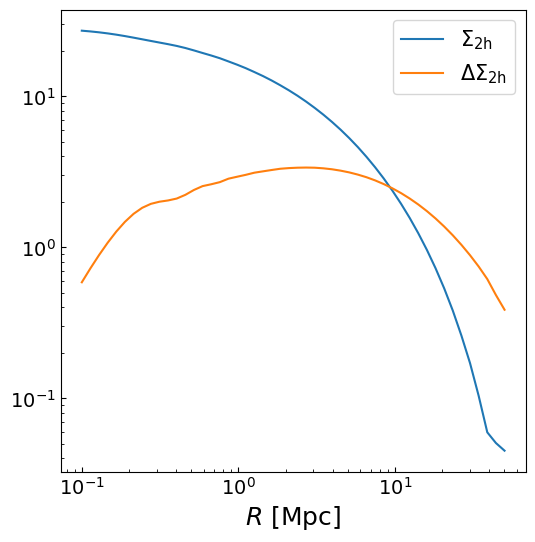

In [17]:
def show_sig_dsig():
    # Compute
    r = np.logspace(-1.0, 1.7, 50)
    z = np.array([1.0])
    mass = np.array([1e14 * background.h])

    from datetime import datetime

    halo_bias = HSTinker.bias(z, mass)

    now = datetime.now()
    Sigma_2h = Sigma_2h_func(r, z, halo_bias)[0, 0]
    print("Time employed for computing Sigma(R):", datetime.now() - now)

    now = datetime.now()
    DeltaSigma_2h = DeltaSigma_2h_func(r, z, halo_bias)[0, 0]
    print("Time employed for computing DeltaSigma(R):", datetime.now() - now)

    # Plot
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.xaxis.set_tick_params(direction="in", which="both", labelsize=14)
    ax.yaxis.set_tick_params(direction="in", which="both", labelsize=14)
    ax.set_xlabel(r"$R$ [Mpc]", fontsize=18)
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.plot(r, Sigma_2h, label=r"$\Sigma_{\rm 2h}$")
    ax.plot(r, DeltaSigma_2h, label=r"$\Delta\Sigma_{\rm 2h}$")

    ax.legend(loc="upper right", fontsize=15)
    plt.show()


show_sig_dsig()

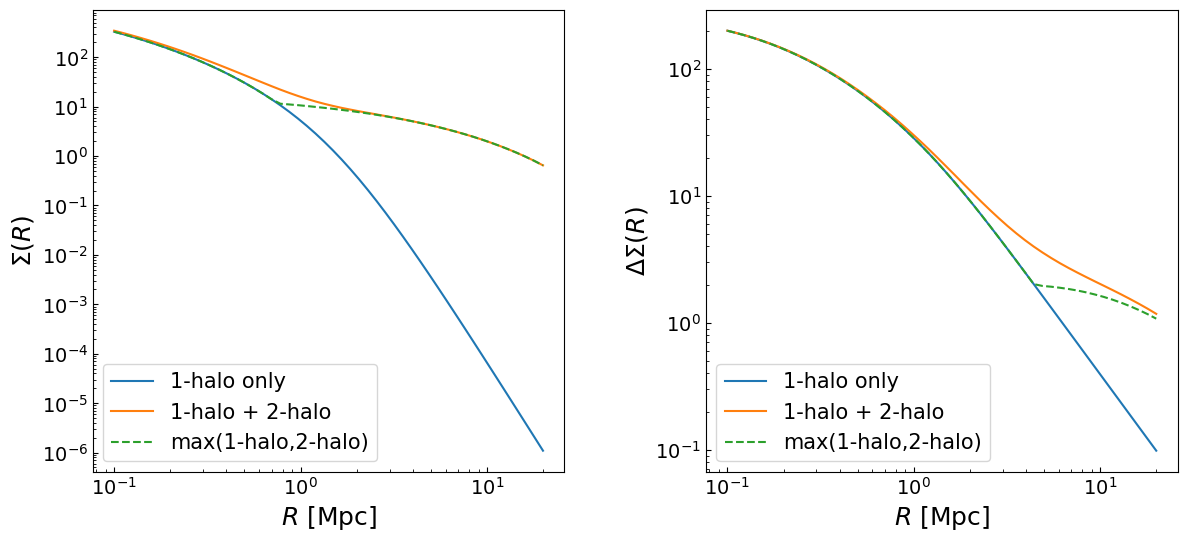

In [18]:
def show_sig_dsig2():
    r = np.logspace(-1.0, 1.3, 50)
    z = np.array([0.5])
    conc = 3.0
    mass = np.array([1e14 * background.h])

    profileBMO.core.overdensity_type = "crit"
    profileBMO.core.overdensity = 200
    halo_bias = HSTinker.bias(z, mass)

    # Compute Sigma and DeltaSigma - only 1-halo
    profileBMO.two_halo = "None"
    Sigma = profileBMO.surface_mass_density(r, z, mass, conc, halo_bias)[0][0]
    DeltaSigma = profileBMO.excess_surface_mass_density(r, z, mass, conc, halo_bias)[0][
        0
    ]

    # Compute Sigma and DeltaSigma - including 2-halo (sum)
    profileBMO.two_halo = "sum"
    Sigma_2h_sum = profileBMO.surface_mass_density(r, z, mass, conc, halo_bias)[0][0]
    DeltaSigma_2h_sum = profileBMO.excess_surface_mass_density(
        r, z, mass, conc, halo_bias
    )[0][0]

    # Compute Sigma and DeltaSigma - including 2-halo (max)
    profileBMO.two_halo = "max"
    Sigma_2h_max = profileBMO.surface_mass_density(r, z, mass, conc, halo_bias)[0][0]
    DeltaSigma_2h_max = profileBMO.excess_surface_mass_density(
        r, z, mass, conc, halo_bias
    )[0][0]

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"wspace": 0.3})

    for i in range(len(ax)):
        ax[i].xaxis.set_tick_params(direction="in", which="both", labelsize=14)
        ax[i].yaxis.set_tick_params(direction="in", which="both", labelsize=14)
        ax[i].set_xlabel(r"$R$ [Mpc]", fontsize=18)
        ax[i].set_xscale("log")
        ax[i].set_yscale("log")
    ax[0].set_ylabel(r"$\Sigma(R)$", fontsize=18)
    ax[1].set_ylabel(r"$\Delta\Sigma(R)$", fontsize=18)

    ax[0].plot(r, Sigma, label="1-halo only")
    ax[0].plot(r, Sigma_2h_sum, label="1-halo + 2-halo")
    ax[0].plot(r, Sigma_2h_max, label="max(1-halo,2-halo)", linestyle="dashed")

    ax[1].plot(r, DeltaSigma, label="1-halo only")
    ax[1].plot(r, DeltaSigma_2h_sum, label="1-halo + 2-halo")
    ax[1].plot(r, DeltaSigma_2h_max, label="max(1-halo,2-halo)", linestyle="dashed")

    ax[0].legend(loc="lower left", fontsize=15)
    ax[1].legend(loc="lower left", fontsize=15)
    plt.show()

show_sig_dsig2()

Now we validate our 2-halo implementations with both **COMB-CL** and **CosmoBolognaLib** (CBL).

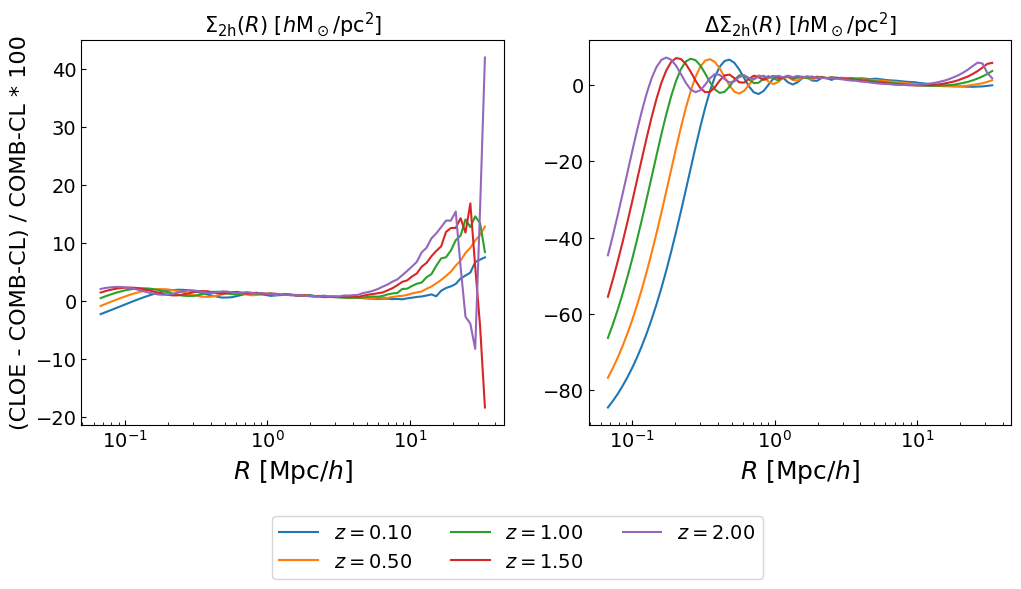

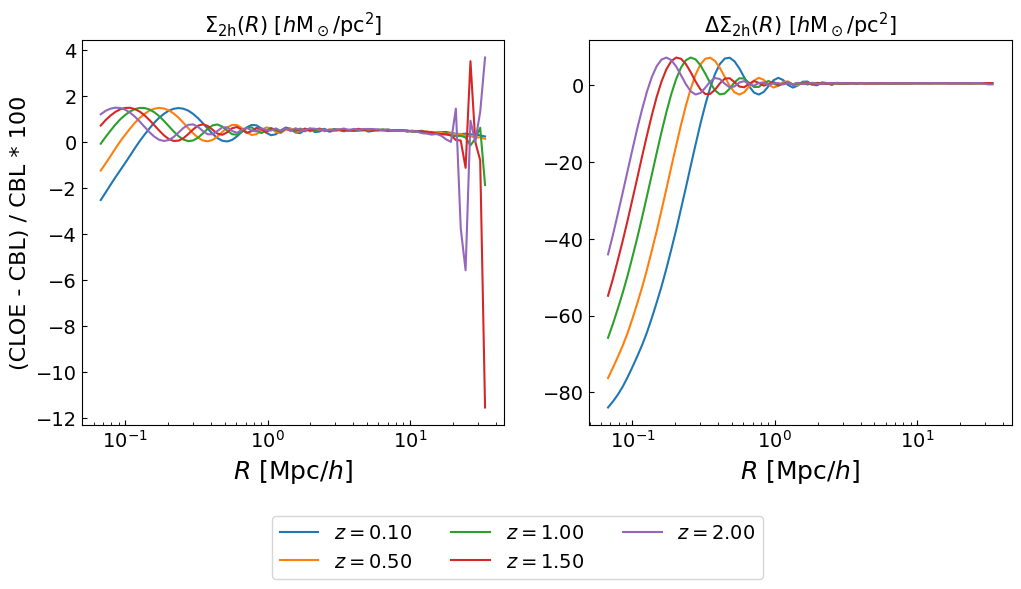

In [19]:
def validate_2h(ddir, file, z, mass, bias, ylabel):

    # Read the validation files
    table_validation = np.genfromtxt(os.path.join(ddir, file)).T

    rad = table_validation[0] * background.h  # Mpc/h
    table_validation = (
        np.delete(table_validation, 0, axis=0) / background.h
    )  # Ms pc^{-2} h

    Sigma = Sigma_2h_func(rad, z, bias)
    DeltaSigma = DeltaSigma_2h_func(rad, z, bias)

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"wspace": 0.2})

    for i in range(len(ax)):
        ax[i].xaxis.set_tick_params(direction="in", which="both", labelsize=14)
        ax[i].yaxis.set_tick_params(direction="in", which="both", labelsize=14)
        ax[i].set_xlabel(r"$R$ [Mpc$/h$]", fontsize=18)
        ax[i].set_xscale("log")
    ax[0].set_ylabel(ylabel, fontsize=16)

    ax[0].set_title(r"$\Sigma_{\rm 2h}(R)$ [$h$M$_\odot$/pc$^2$]", fontsize=15)
    ax[1].set_title(r"$\Delta\Sigma_{\rm 2h}(R)$ [$h$M$_\odot$/pc$^2$]", fontsize=15)

    idx = 0
    for i in range(len(z)):
        ax[0].plot(
            rad,
            (Sigma[i][0] - table_validation[idx]) / table_validation[idx] * 100.0,
            label=r"$z=$" + str("{:.2f}".format(z[i])),
        )
        idx += 1
        ax[1].plot(
            rad,
            (DeltaSigma[i][0] - table_validation[idx]) / table_validation[idx] * 100.0,
            label=r"$z=$" + str("{:.2f}".format(z[i])),
        )
        idx += 1

    ax[0].legend(loc=(0.45, -0.4), fontsize=14, ncol=3)
    plt.show()


# »»»»»»»»»»»»»»»»»»»»»»»»»»»»»


z = np.array([0.1, 0.5, 1.0, 1.5, 2.0])  # shape (5,)
mass = np.array([1e14 * background.h] * 4)  # shape (4,)
bias = np.array([2.0] * 4)  # shape (4,)
bias = np.tile(bias[np.newaxis, :], (len(z), 1))  # shape (5, 4)

validate_2h(
    DeltaSigma_dir,
    "DeltaSigmaR_2halo_zTest.txt",
    z,
    mass,
    bias,
    ylabel="(CLOE - COMB-CL) / COMB-CL * 100",
)
validate_2h(
    DeltaSigma_dir,
    "DeltaSigmaR_2halo_zTest_CBL.txt",
    z,
    mass,
    bias,
    ylabel="(CLOE - CBL) / CBL * 100",
)

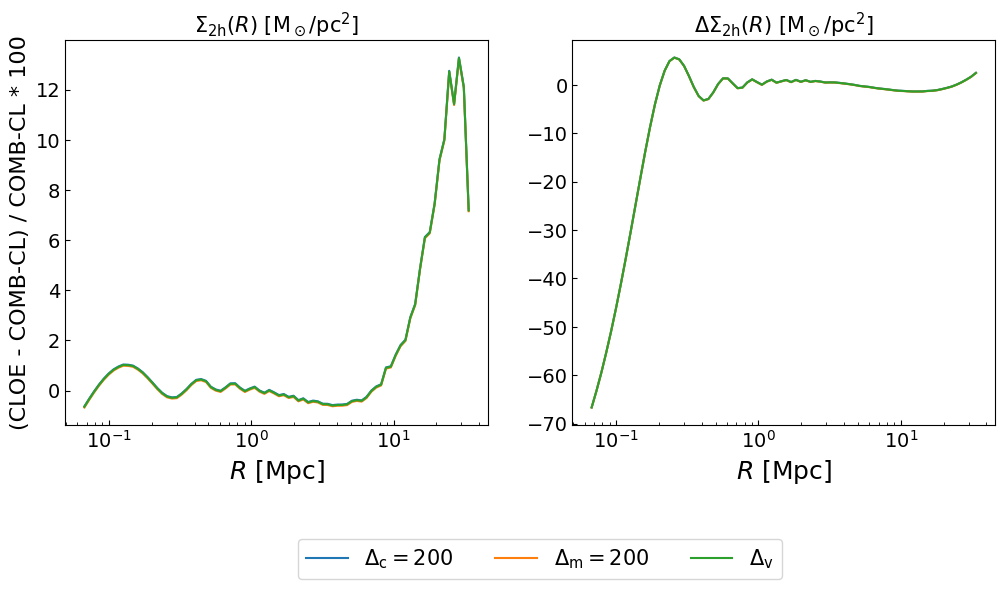

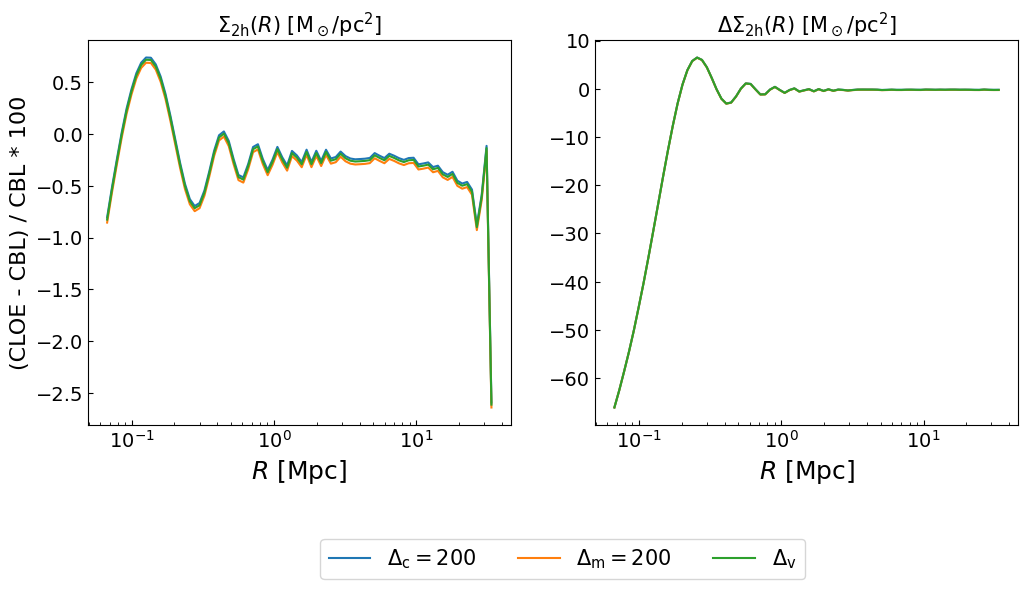

In [20]:
def validate_2h(ddir, file, z, mass, Delta, DeltaType, ylabel):

    HSTinker.overdensity = Delta

    # Read the validation files
    table_validation = np.genfromtxt(os.path.join(ddir, file)).T

    rad = table_validation[0] * background.h  # Mpc/h
    table_validation = (
        np.delete(table_validation, 0, axis=0) / background.h
    )  # Ms pc^{-2} h

    # Compute Sigma and DeltaSigma with CLOE\n",
    Sigma, DeltaSigma = [], []

    for delta_type in DeltaType:
        HSTinker.overdensity_type = delta_type
        halo_bias = HSTinker.bias(z, mass)
        Sigma.append(Sigma_2h_func(rad, z, halo_bias))
        DeltaSigma.append(DeltaSigma_2h_func(rad, z, halo_bias))

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"wspace": 0.2})

    for i in range(len(ax)):
        ax[i].xaxis.set_tick_params(direction="in", which="both", labelsize=14)
        ax[i].yaxis.set_tick_params(direction="in", which="both", labelsize=14)
        ax[i].set_xlabel(r"$R$ [Mpc]", fontsize=18)
        ax[i].set_xscale("log")
    ax[0].set_ylabel(ylabel, fontsize=16)

    ax[0].set_title(r"$\Sigma_{\rm 2h}(R)$ [M$_\odot$/pc$^2$]", fontsize=15)
    ax[1].set_title(r"$\Delta\Sigma_{\rm 2h}(R)$ [M$_\odot$/pc$^2$]", fontsize=15)

    idx = 0
    for i in range(len(DeltaType)):

        if DeltaType[i] == "crit":
            str_Delta = r"$\Delta_{\rm c}=$" + str("{:.0f}".format(Delta))
        elif DeltaType[i] == "mean":
            str_Delta = r"$\Delta_{\rm m}=$" + str("{:.0f}".format(Delta))
        elif DeltaType[i] == "vir":
            str_Delta = r"$\Delta_{\rm v}$"

        ax[0].plot(
            rad,
            (Sigma[i][0][0] - table_validation[idx]) / table_validation[idx] * 100.0,
            label=str_Delta,
        )
        idx += 1
        ax[1].plot(
            rad,
            (DeltaSigma[i][0][0] - table_validation[idx])
            / table_validation[idx]
            * 100.0,
            label=str_Delta,
        )
        idx += 1

    ax[0].legend(loc=(0.55, -0.4), fontsize=15, ncol=3)
    plt.show()


# »»»»»»»»»»»»»»»»»»»»»»»»»»»»»

Delta = 200
DeltaType = ["crit", "mean", "vir"]
z = np.array([1.0])
mass = np.array([1e14 * background.h])

validate_2h(
    DeltaSigma_dir,
    "DeltaSigmaR_2halo_DeltaTest.txt",
    z,
    mass,
    Delta,
    DeltaType,
    ylabel="(CLOE - COMB-CL) / COMB-CL * 100",
)
validate_2h(
    DeltaSigma_dir,
    "DeltaSigmaR_2halo_DeltaTest_CBL.txt",
    z,
    mass,
    Delta,
    DeltaType,
    ylabel="(CLOE - CBL) / CBL * 100",
)

### Off-centered profiles <a class="anchor" id="chapt1_2_2"></a>

Now we validate the implementations of the off-centered profiles.

Being skipped for now

In [ ]:
if False:
    # Set the fixed parameters
    z = np.array([0.5])
    conc = 4.0
    mass = 1.0e14
    r = np.logspace(-1.9, 1.7, 80)

    # 1-halo
    clusters = CG(
        like.cosmo.cosmo_dic,
        CG_ricH_seL_funcT,
        "NFW",
        "crit",
        200,
        two_halo="None",
        offcentering=False,
        rms_off=0.0,
        f_off=0.0,
    )
    DeltaSigma_cen = clusters.excess_surface_mass_density(r, z, conc, mass)[0]

    clusters = CG(
        like.cosmo.cosmo_dic,
        CG_ricH_seL_funcT,
        "NFW",
        "crit",
        200,
        two_halo="None",
        offcentering=True,
        rms_off=0.3,
        f_off=0.3,
    )
    DeltaSigma_off = clusters.excess_surface_mass_density(r, z, conc, mass)[0]

    # 1-halo + 2-halo
    clusters = CG(
        like.cosmo.cosmo_dic,
        CG_ricH_seL_funcT,
        "NFW",
        "crit",
        200,
        two_halo="sum",
        offcentering=False,
        rms_off=0.0,
        f_off=0.0,
    )
    DeltaSigma_cen_2h = clusters.excess_surface_mass_density(r, z, conc, mass)[0]

    clusters = CG(
        like.cosmo.cosmo_dic,
        CG_ricH_seL_funcT,
        "NFW",
        "crit",
        200,
        two_halo="sum",
        offcentering=True,
        rms_off=0.3,
        f_off=0.3,
    )
    DeltaSigma_off_2h = clusters.excess_surface_mass_density(r, z, conc, mass)[0]

    # max(1-halo, 2-halo)
    clusters = CG(
        like.cosmo.cosmo_dic,
        CG_ricH_seL_funcT,
        "NFW",
        "crit",
        200,
        two_halo="max",
        offcentering=False,
        rms_off=0.0,
        f_off=0.0,
    )
    DeltaSigma_cen_2h_max = clusters.excess_surface_mass_density(r, z, conc, mass)[0]

    clusters = CG(
        like.cosmo.cosmo_dic,
        CG_ricH_seL_funcT,
        "NFW",
        "crit",
        200,
        two_halo="max",
        offcentering=True,
        rms_off=0.3,
        f_off=0.3,
    )
    DeltaSigma_off_2h_max = clusters.excess_surface_mass_density(r, z, conc, mass)[0]

    # Set the plot
    fig, ax = plt.subplots(
        2,
        3,
        figsize=(15, 7),
        gridspec_kw={"hspace": 0, "wspace": 0, "height_ratios": [1, 0.3]},
        sharex="col",
        sharey="row",
    )

    for i in range(len(ax)):
        for j in range(len(ax[i])):
            ax[i][j].xaxis.set_tick_params(direction="in", which="both", labelsize=14)
            ax[i][j].yaxis.set_tick_params(direction="in", which="both", labelsize=14)
            ax[i][j].set_xscale("log")
            ax[1][j].set_xlabel(r"$R$ [Mpc]", fontsize=16)
    ax[0][0].set_ylabel(r"$\Delta\Sigma(R)$", fontsize=16)
    ax[0][0].set_yscale("log")

    # Plot the functions
    ax[0][0].plot(r, DeltaSigma_cen, label="Centered")
    ax[0][0].plot(
        r, DeltaSigma_off, label="Including off-centering", linestyle="dashed"
    )
    ax[1][0].plot(
        r, (DeltaSigma_cen - DeltaSigma_off) / DeltaSigma_off * 100.0, color="k"
    )

    ax[0][1].plot(r, DeltaSigma_cen_2h, label="Centered")
    ax[0][1].plot(
        r, DeltaSigma_off_2h, label="Including off-centering", linestyle="dashed"
    )
    ax[1][1].plot(
        r,
        (DeltaSigma_cen_2h - DeltaSigma_off_2h) / DeltaSigma_off_2h * 100.0,
        color="k",
    )

    ax[0][2].plot(r, DeltaSigma_cen_2h_max, label="Centered")
    ax[0][2].plot(
        r, DeltaSigma_off_2h_max, label="Including off-centering", linestyle="dashed"
    )
    ax[1][2].plot(
        r,
        (DeltaSigma_cen_2h_max - DeltaSigma_off_2h_max) / DeltaSigma_off_2h_max * 100.0,
        color="k",
    )

    # Final plot settings and show
    ax[1][0].set_ylabel("% diff.", fontsize=16)
    ax[0][0].legend(title="1-halo", title_fontsize=14, loc="lower left", fontsize=14)
    ax[0][1].legend(
        title="1-halo + 2-halo", title_fontsize=14, loc="lower left", fontsize=14
    )
    ax[0][2].legend(
        title="max(1-halo, 2-halo)", title_fontsize=14, loc="lower left", fontsize=14
    )
    plt.show()

In [ ]:
if False:

    def validate_off(ddir, file, sigma_off, ylabel):

        z = np.array([0.5])
        mass = 1.0e14
        conc = 4.0

        # Read the validation files
        table_validation = np.genfromtxt(os.path.join(ddir, file)).T

        rad = np.array(table_validation[0])
        table_validation = np.delete(table_validation, 0, axis=0)

        # Compute Sigma and DeltaSigma with CLOE
        table = []

        for i in range(len(sigma_off)):
            clusters = CG(
                like.cosmo.cosmo_dic,
                like.cosmo.cosmo_dic,
                CG_ricH_seL_funcT,
                "NFW",
                "crit",
                200,
                two_halo="None",
                offcentering=True,
                rms_off=sigma_off[i],
                f_off=1.0,
            )
            table.append(clusters.excess_surface_mass_density(rad, z, conc, mass)[0])

        table = np.asarray(table)

        # Plot
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.xaxis.set_tick_params(direction="in", which="both", labelsize=14)
        ax.yaxis.set_tick_params(direction="in", which="both", labelsize=14)
        ax.set_xlabel(r"$R$ [Mpc]", fontsize=18)
        ax.set_xscale("log")
        ax.set_ylabel(ylabel, fontsize=16)

        ax.set_title(r"$\Delta\Sigma_{\rm off}(R)$ [M$_\odot$/pc$^2$]", fontsize=15)

        for i in range(len(sigma_off)):
            ax.plot(
                rad,
                (table[i] - table_validation[i]) / table_validation[i] * 100.0,
                label=r"$\sigma_{\rm off}=$" + str((sigma_off[i])),
            )

        ax.legend(loc=(-0.3, -0.4), fontsize=14, ncol=3)
        plt.show

    # »»»»»»»»»»»»»»»»»»»»»»»»»»»»»

    sigma_off = [1.0e-4, 1.0e-3, 1.0e-2, 1.0e-1, 0.5, 1.0]
    bias = 2.0

    validate_off(
        truth_dir,
        "DeltaSigmaR_off.txt",
        sigma_off,
        ylabel="(CLOE - COMB-CL) / COMB-CL * 100",
    )

## Clustering <a class="anchor" id="chapt1_3"></a>

The cluster clustering can be computed with the `HaloClustering` type class.

(showing of the results to be added)

In [ ]:
if False:
    haloClustering = TwoPoint3DHaloClustering(background, background_fid)

# Galaxy Cluster Summary Statistics <a class="anchor" id="chapt2"></a>

First, we need to create a `ClusterStatisticsModeling` that will be used as the core mechanism to compute the cluster summary statitstics:

In [ ]:
# HMF parameters

area = 10313
overdensity_type = "vir"

# Arrays for internal integrations

integ_k_arr = np.geomspace(1e-4, 10, 500)
integ_mass_arr = np.logspace(12.0, 16.0, 51)
integ_lambda_true_arr = np.geomspace(5.0, 250.0, 51)
integ_ztrue_arr = np.linspace(1.0e-5, 2.0 - 1.0e-5, 51)

In [ ]:
# Istanciate objects
HSCastro_nonu = CastroHaloAbundance(
    matter_statistics=MatterStatistics(
        perturbations,
        z=integ_ztrue_arr,
        k=integ_k_arr,
    )
)

In [ ]:
# We also need a selection function for each probe
halo_mass_observable = LognormalPowerLawHaloMassObservable(
    A_l=52.0,
    B_l=0.9,
    C_l=0.5,
    sig_A_l=0.2,
    sig_B_l=-0.05,
    sig_C_l=0.001,
)
selection_parameters = dict(
    sig_lambda_norm=0.9,
    sig_lambda_z=0.1,
    sig_lambda_exponent=0.4,
    sig_z_z=0.025,
    sig_z_lambda=5.0e-6,
    halo_mass_observable=halo_mass_observable,
)

selection_function_counts = GaussianSelectionFunction(
    **selection_parameters,
    lambda_tab_integ=[31, 31, 31, 51],
    z_tab_integ=31,
)
selection_function_profiles = GaussianSelectionFunction(
    **selection_parameters,
    lambda_tab_integ=[31, 31, 31, 51],
    z_tab_integ=31,
)
selection_function_clustering = GaussianSelectionFunction(
    **selection_parameters,
    lambda_tab_integ=[31, 51],
    z_tab_integ=31,
)

In [ ]:
# Create cluster statistics modeling object
from cloelib.summary_statistics.clusters import ClusterStatisticsModeling

integ_ztrue_arr_new = integ_ztrue_arr.copy()
integ_ztrue_arr_new[0] += 1.0e-10
integ_ztrue_arr_new[-1] -= 1.0e-10

integ_k_arr_new = integ_k_arr.copy()
integ_k_arr_new[0] += 1.0e-10
integ_k_arr_new[-1] -= 1.0e-10

cluster_statitstics_modeling = ClusterStatisticsModeling(
    HSCastro_nonu,
    integ_k_arr=integ_k_arr_new,
    integ_mass_arr=integ_mass_arr,
    integ_lambda_true_arr=integ_lambda_true_arr,
    integ_ztrue_arr=integ_ztrue_arr_new,
    area=area,
)

## Number counts <a class="anchor" id="chapt2_1"></a>

The binned number counts is computed by the `ClusterCounts` object,
which takes the `ClusterStatisticsModeling`, `HaloCovariance` objects and `photoz_rsd_correction` function
as an input:

In [ ]:
# Istanciate objects
haloClustering = TwoPoint3DHaloClustering(
    matter_statistics=MatterStatistics(
        perturbations,
        z=integ_ztrue_arr,
        k=integ_k_arr,
    ),
    background_fid=background_fid,
)

In [ ]:
# Istanciate counts summary statistcs object
from cloelib.summary_statistics.clusters import ClusterCounts

cluster_counts_statistics = ClusterCounts(
    cluster_statitstics_modeling,
    covariance,
    selection_function=selection_function_counts,
)

### Counts

To get the cluster counts, we just need to call the `get_NC` function.


Notice that this function also returns an auxiliary product `counts_intermediate_integration_products`.
This is a dictionary containing:


  - **window_lambda_obs** (numpy.ndarray) : Integral of P(lamda_obs|M, ztrue) in lambda_obs bins.
  - **window_z_obs** (numpy.ndarray) : Integral of P(z_obs|lambda_obs, ztrue) in z_obs bins.

These will be used for the computation of the cluster covariance.

In [ ]:
# Define probe bins
z_obs_nc_edges = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6])
lambda_obs_nc_edges = np.array([20.0, 30.0, 45.0, 60.0, 500.0])

In [ ]:
t0 = time.time()
cluster_counts, counts_intermediate_integration_products = (
    cluster_counts_statistics.get_NC(
        z_obs_edges=z_obs_nc_edges,
        lambda_obs_edges=lambda_obs_nc_edges,
    )
)
print(f"nc        :  {time.time()-t0:.4f} seconds")

Show validation:

In [ ]:
# Read measures and expectation values
measure = np.load(os.path.join(nc_dir, "NC_data_lam_lg20_02_z_16.npy"))
model_tr = np.genfromtxt(os.path.join(nc_dir, "NC_CG_CC_model.dat"))


# For plotting
l_ob_mean = np.array([23.8714427, 35.64512875, 51.13983791, 79.60670823])


# Set the plot
fig, ax = plt.subplots(
    6,
    3,
    figsize=(16, 18),
    sharey="row",
    gridspec_kw={"hspace": 0, "wspace": 0, "height_ratios": [1, 0.5, 1, 0.5, 1, 0.5]},
)
for i in range(len(ax)):
    for j in range(len(ax[i])):
        ax[i][j].xaxis.set_tick_params(direction="in", which="both", labelsize=14)
        ax[i][j].yaxis.set_tick_params(direction="in", which="both", labelsize=14)
        # ax[i][j].set_xscale("log")
        if i % 2 == 0:
            ax[i][j].set_yscale("log")
        if j == 0:
            if i % 2 == 0:
                ax[i][j].set_ylabel(
                    r"$N\,(\Delta\lambda^{\rm ob},\Delta z^{\rm ob})$", fontsize=16
                )
            else:
                ax[i][j].set_ylabel(r"% diff.", fontsize=16)

fig.delaxes(ax[4][1])
fig.delaxes(ax[5][1])
fig.delaxes(ax[4][2])
fig.delaxes(ax[5][2])

ax[5][0].set_xlabel(r"$\lambda^{\rm ob}$", fontsize=18)
ax[3][1].set_xlabel(r"$\lambda^{\rm ob}$", fontsize=18)
ax[3][2].set_xlabel(r"$\lambda^{\rm ob}$", fontsize=18)


# Plot
def plot_validation(ax1, ax2, z_idx):

    if z_idx == 0:
        labelspacing = 0.5
        label_measure = "Measure"
        label_model_tr = "Reference model"
        label_model_theo = "CLOE model"
    else:
        labelspacing = 0.0
        label_measure = None
        label_model_tr = None
        label_model_theo = None

    # Measure
    ax1.errorbar(
        l_ob_mean,
        measure[z_idx],
        np.sqrt(measure[z_idx]),
        color="k",
        capsize=5,
        fmt="o",
        label=label_measure,
    )

    # Reference model
    ax1.plot(
        l_ob_mean,
        cluster_counts[z_idx],
        color="k",
        linestyle="solid",
        label=label_model_tr,
    )

    # CLOE model
    ax1.plot(
        l_ob_mean,
        cluster_counts[z_idx],
        color="r",
        linestyle="dashed",
        label=label_model_theo,
    )

    ax1.legend(
        loc="upper right",
        fontsize=13,
        title_fontsize=13,
        labelspacing=labelspacing,
        title=r"$z\in["
        + str(z_obs_nc_edges[z_idx])
        + ","
        + str(z_obs_nc_edges[z_idx + 1])
        + "]$",
    )

    # Plot % differences
    ax2.plot(
        l_ob_mean,
        (measure[z_idx] - cluster_counts[z_idx]) / cluster_counts[z_idx] * 100,
        color="b",
        linestyle="dashed",
        label="CLOE vs Measure",
    )
    ax2.plot(
        l_ob_mean,
        (model_tr[z_idx] - cluster_counts[z_idx]) / cluster_counts[z_idx] * 100,
        color="g",
        linestyle="solid",
        label="CLOE vs Reference model",
    )

    if z_idx == 0:
        ax2.legend(loc="lower center", fontsize=12)
    ax1.set_ylim(1e2, 4e4)


z_idx = 0
for i in range(len(ax[0])):
    plot_validation(ax[0][i], ax[1][i], z_idx)
    z_idx += 1
for i in range(len(ax[2])):
    plot_validation(ax[2][i], ax[3][i], z_idx)
    z_idx += 1
plot_validation(ax[4][0], ax[5][0], z_idx)

plt.show()

### Counts covariance

We can compute the counts covariance using the intermediate products returned from `ClusterCounts.get_NC`:

In [ ]:
t0 = time.time()
cov_cluster_counts = cluster_counts_statistics.get_NC_covariance(
    z_obs_nc_edges,
    cluster_counts,
    counts_intermediate_integration_products["window_lambda_obs"],
    counts_intermediate_integration_products["window_z_obs"],
)
print(f"nc_cov    :  {time.time()-t0:.4f} seconds")

In [ ]:
plt.rcParams["xtick.labelsize"] = 13.0
plt.rcParams["ytick.labelsize"] = 13.0
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True

Show validation:

In [ ]:
# truth tables for number counts and covariance from an external code
truth = np.load(os.path.join(nc_dir, "NC_CG_CC_nc_and_cov.npz"))
nc_tt = truth["nc"]
cov_nc_tt = truth["cov"]


# plot setup
cvec = [
    "dimgray",
    "#1d5dec",
    "teal",
    "forestgreen",
    "darkorange",
    "crimson",
    "purple",
    "#5729ce",
]
cvec1 = ["lightgray", "skyblue", "c", "#d0fe1d", "gold", "salmon", "plum", "#c1c6fc"]

fig = plt.figure(0, figsize=(8, 7))
ax_0_a = fig.add_axes([0.2, 0.3, 0.7, 0.6], xticklabels=[])
ax_0_b = fig.add_axes([0.2, 0.10, 0.7, 0.2])

z_obs_mean = (z_obs_nc_edges[1:] + z_obs_nc_edges[:-1]) / 2

plt.sca(ax_0_a)
for iz in range(len(z_obs_mean)):
    plt.semilogy(
        l_ob_mean,
        cluster_counts[iz],
        c=cvec1[iz],
        lw=2.0,
        label=r"$z_{\rm m}$=%1.1f" % z_obs_mean[iz],
    )
    plt.semilogy(l_ob_mean, nc_tt[iz], "--", c=cvec[iz], lw=2.0)
    plt.legend(loc=3, fontsize=15, ncol=1, framealpha=0.85)

plt.ylabel("$N(\lambda)$", fontsize=20)
plt.xlim([21, 82])
plt.title(r"-- CLOE, -- -- truth table", fontsize=20)

plt.sca(ax_0_b)
for iz in range(len(z_obs_mean)):
    plt.plot(l_ob_mean, (cluster_counts[iz] / nc_tt[iz] - 1) * 100, lw=2.0, c=cvec[iz])

plt.fill_between([10, 160], -2, 2, color="lightgray", alpha=0.4, label="2\% area")
plt.axhline(0, c="k", ls="--")

plt.xlim([21, 82])
plt.ylim([-7, 7])
plt.ylabel("$\Delta N$/$N_\mathrm{tr}$ (\%)", fontsize=18)
plt.xlabel("$\lambda $", fontsize=18)
# plt.xscale('log')
plt.legend(loc=0, fontsize=14)

In [ ]:
colvec1 = ["skyblue", "salmon", "gold", "limegreen"]
colvec2 = ["dodgerblue", "crimson", "#f5bf03", "forestgreen"]

i = 0
fig = plt.figure(iz, figsize=(8.5, 7))
ax_0_a = fig.add_axes([0.2, 0.3, 0.6, 0.6], xticklabels=[])
ax_0_b = fig.add_axes([0.2, 0.10, 0.6, 0.2])

z_ob_mean = (z_obs_nc_edges[1:] + z_obs_nc_edges[:-1]) / 2

plt.sca(ax_0_a)

for j in range(3):
    plt.plot(
        z_ob_mean,
        np.diag(cov_cluster_counts[:, :, i, i + j]),
        "-",
        c=colvec1[j],
        lw=2.2,
        label=r"$C_{i\,i\,0\,%s}$" % j,
    )
    # print(np.diag(cov_zbin_Lbin[:,:,i,i+j]))
    plt.plot(
        z_ob_mean, np.diag(cov_nc_tt[:-1, :-1, i, i + j]), "--", c=colvec2[j], lw=2.2
    )

plt.plot(
    z_ob_mean[:-1],
    np.diag(cov_cluster_counts[:, 1:, i, i]),
    "-",
    c=colvec1[3],
    lw=2.2,
    label=r"$C_{i\,(i+1)\,0\,0}$",
)
plt.plot(
    z_ob_mean[:-1], np.diag(cov_nc_tt[:-2, 1:-1, i, i]), "--", c=colvec2[3], lw=2.2
)


# plt.axhline(0, c='k', linestyle='--', lw=1)
plt.legend(loc=1, fontsize=15, framealpha=0.75)
plt.ylabel("Covariance terms", fontsize=14, labelpad=8)
plt.xticks(z_ob_mean, [])
plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0), useMathText=True)
plt.title(r"-- CLOE, -- -- truth table", fontsize=20)


plt.sca(ax_0_b)

cov_diff = (cov_cluster_counts / cov_nc_tt[:-1, :-1] - 1) * 100
for j in range(3):
    plt.plot(z_ob_mean, np.diag(cov_diff[:, :, i, i + j]), c=colvec1[j], linewidth=2.2)
plt.plot(z_ob_mean[:-1], np.diag(cov_diff[:-1, 1:, i, i]), c=colvec1[3], linewidth=2.2)

plt.xlabel("redshift", fontsize=14, labelpad=5)
plt.ylabel("$\Delta C$/$C_\mathrm{tr}$ (\%)", fontsize=18)
plt.axhline(0, color="k", linestyle="--", linewidth=1)
plt.xticks(z_ob_mean, rotation=30)
# plt.ylim(-8,8)
pass

## Weak Lensing Profiles <a class="anchor" id="chapt2_2"></a>

The weak lensing profiles are computed by the `ClusterWeakLensing` object,
which takes the `ClusterStatisticsModeling`, `Profile` objects and a `halo_concentration` value
as an input:

In [ ]:
# Istanciate wl summary statistcs object
from cloelib.summary_statistics.clusters import ClusterWeakLensing

cluster_wl_statistics = ClusterWeakLensing(
    cluster_statitstics_modeling,
    profileNFW,
    halo_concentration=halo_concentration,
    selection_function=selection_function_profiles,
)

### Reduced Shear Profiles

To get the Reduce Shear ($g_t$) profile, we just need to call the `get_gt` function.

>Note: It is also possible to compute the Excess Surface Density ($\Delta\Sigma$) profile with the `get_DeltaSigma` function.

In [ ]:
# Define probe bins
z_obs_profile_edges = np.linspace(0.2, 1.8, 9)
lambda_obs_profile_edges = np.array([20.0, 30.0, 45.0, 60.0, 500.0])
radius_profile_edges = np.linspace(5.0, 100.0, 11)

In [ ]:
# Get probe in bins
t0 = time.time()
deltasigma_mean_values = cluster_wl_statistics.get_gt(
    z_obs_edges=z_obs_profile_edges,
    lambda_obs_edges=lambda_obs_profile_edges,
    radius_edges=radius_profile_edges,
)
print(f"dsig      :  {time.time()-t0:.4f} seconds")

## Clustering <a class="anchor" id="chapt2_3"></a>

The 2-point correlation function in computed by the `ClusterClustering` object,
which takes the `ClusterStatisticsModeling` and `HaloClustering` type objects as an input:

In [ ]:
# Istanciate cluster xi summary statistcs object
from cloelib.summary_statistics.clusters import ClusterClustering

cluster_clustering_statistics = ClusterClustering(
    cluster_statitstics_modeling,
    haloClustering,
    selection_function=selection_function_clustering,
)

### 2-point correlation function

To get the cluster 2 point correlation function $\xi$, we just need to call the `get_xi` function.


Notice that this function also returns an auxiliary product `clustering_intermediate_integration_products`.
This is a dictionary containing:

  - **pk_mean_values** (numpy.ndarray) : Power spectrum averaged on redshift and richnesses bins (with IR-resummation).
  - **radial_shell_window** (numpy.ndarray) : Cluster count covariance window (z_obs, lambda_obs, k).
  - **radial_shell_volume** (numpy.ndarray) : Spherical shell volume (z_obs, radius).
  - **window_z_obs** (numpy.ndarray) : Integral of P(z_obs|lambda_obs, ztrue) in z_obs bins.
  - **cluster_counts** (numpy.ndarray) :  Number counts in redshift and richness bins

These will be used for the computation of the 2-point correlation function covariance.

In [ ]:
# Define probe bins
lambda_obs_clustering_edges = np.array([20, 30, 500])
radius_clustering_edges = np.geomspace(20.0, 130.0, 31)
zed_obs_clustering_edges = np.arange(0.2, 1.81, 0.4)

In [ ]:
# Get probe in bins
t0 = time.time()
cluster_clustering, clustering_intermediate_integration_products = (
    cluster_clustering_statistics.get_xi(
        lambda_obs_edges=lambda_obs_clustering_edges,
        radius_edges=radius_clustering_edges,
        z_obs_edges=zed_obs_clustering_edges,
    )
)
print(f"xi        :  {time.time()-t0:.4f} seconds")

Show validation:

In [ ]:
# truth tables for clustering and covariance from an external code
truth = np.load(os.path.join(clustering_dir, "xi_CG_CL_xi_and_cov.npz"))
xi2_tt = truth["xi"]
cov_xi2_tt = truth["cov"]

zed_obs_Cxi2_edges = np.arange(0.2, 1.81, 0.4)
zed_obs_Cxi2_div = len(zed_obs_clustering_edges) - 1

# plot setup
cvec = ["#1d5dec", "forestgreen", "darkorange", "crimson"]
cvec1 = ["skyblue", "#d0fe1d", "gold", "salmon"]

fig = plt.figure(0, figsize=(8, 7))
ax_0_a = fig.add_axes([0.2, 0.3, 0.7, 0.6], xticklabels=[])
ax_0_b = fig.add_axes([0.2, 0.10, 0.7, 0.2])

r_ob_center_xi = 10 ** (
    (np.log10(radius_clustering_edges[1:]) + np.log10(radius_clustering_edges[:-1])) / 2
)

il = 0
jl = 1

plt.sca(ax_0_a)
for iz in range(zed_obs_Cxi2_div):
    plt.loglog(
        r_ob_center_xi,
        cluster_clustering[iz, il + jl, :],
        c=cvec1[iz],
        lw=2.0,
        label="CLOE",
    )
    plt.loglog(
        r_ob_center_xi,
        xi2_tt[iz, il + jl, :],
        "--",
        c=cvec[iz],
        lw=2.0,
        label="truth table",
    )
    if iz == 0:
        plt.legend(loc=3, fontsize=14)

plt.ylabel("$\\xi_{\\rm h}$(r)", fontsize=20)
plt.xlim([19, 135])

plt.xticks(np.array([20, 30, 40, 60, 80, 100, 130]), [])
plt.sca(ax_0_b)
for iz in range(zed_obs_Cxi2_div):
    plt.plot(
        r_ob_center_xi,
        (cluster_clustering / xi2_tt - 1)[iz, il + jl, :] * 100,
        lw=2.0,
        c=cvec[iz],
    )

plt.fill_between([10, 160], -2, 2, color="lightgray", alpha=0.4, label="2\% area")
plt.axhline(0, c="k")

plt.xlim([19, 135])
plt.ylim([-12, 12])
plt.ylabel("$\Delta \\xi$/$\\xi_\mathrm{tr}$ (\%)", fontsize=18)
plt.xlabel(" r [$h^{-1}$ Mpc]", fontsize=18)
plt.xscale("log")
plt.legend(loc=0, fontsize=14)
plt.xticks(
    np.array([20, 30, 40, 60, 80, 100, 130]), np.array([20, 30, 40, 60, 80, 100, 130])
);

### Correlation function covariance covariance

We can compute the counts covariance using the intermediate products returned from `ClusterClustering.get_xi`:

In [ ]:
t0 = time.time()
cov_cluster_clustering = cluster_clustering_statistics.get_xi_covariance(
    clustering_intermediate_integration_products["pk_mean_values"],
    clustering_intermediate_integration_products["radial_shell_window"],
    clustering_intermediate_integration_products["radial_shell_volume"],
    clustering_intermediate_integration_products["window_z_obs"],
    clustering_intermediate_integration_products["cluster_counts"],
)
print(f"xi_cov    :  {time.time()-t0:.4f} seconds")

Show validation:

In [ ]:
cvec = ["#1d5dec", "forestgreen", "crimson"]
cvec1 = ["skyblue", "#d0fe1d", "salmon"]
iz = 2

fig1 = plt.figure(0, figsize=(8.5, 6))
ax_0_a = fig1.add_axes([0.2, 0.3, 0.7, 0.6], xticklabels=[])
ax_0_b = fig1.add_axes([0.2, 0.10, 0.7, 0.2])

plt.sca(ax_0_a)
plt.loglog(
    r_ob_center_xi,
    np.diag(cov_cluster_clustering[iz, iz, 0, 0, :, :]),
    "-",
    lw=2.0,
    color=cvec1[0],
    label="${C_{kab}}^{00}$",
)
plt.loglog(
    r_ob_center_xi,
    np.diag(cov_cluster_clustering[iz, iz, 0, 2, :, :]),
    "-",
    lw=2.0,
    color=cvec1[1],
    label="${C_{kab}}^{02}$",
)
plt.loglog(
    r_ob_center_xi,
    np.diag(cov_cluster_clustering[iz, iz, 2, 2, :, :]),
    "-",
    lw=2.0,
    color=cvec1[2],
    label="${C_{kab}}^{22}$",
)

plt.loglog(
    r_ob_center_xi, np.diag(cov_xi2_tt[iz, iz, 0, 0, :, :]), "--", lw=2.0, color=cvec[0]
)
plt.loglog(
    r_ob_center_xi, np.diag(cov_xi2_tt[iz, iz, 0, 2, :, :]), "--", lw=2.0, color=cvec[1]
)
plt.loglog(
    r_ob_center_xi, np.diag(cov_xi2_tt[iz, iz, 2, 2, :, :]), "--", lw=2.0, color=cvec[2]
)

plt.legend(fontsize=17, loc=1, framealpha=0.8)
plt.ylabel("Covariance", fontsize=18, labelpad=1)

plt.xlim([19, 131])
plt.xticks(np.array([20, 30, 40, 60, 80, 100]), [])

plt.sca(ax_0_b)
plt.plot(
    r_ob_center_xi,
    (
        np.diag(cov_cluster_clustering[iz, iz, 0, 0, :, :])
        / np.diag(cov_xi2_tt[iz, iz, 0, 0, :, :])
        - 1
    )
    * 100,
    "-",
    lw=2.0,
    color=cvec1[0],
)
plt.plot(
    r_ob_center_xi,
    (
        np.diag(cov_cluster_clustering[iz, iz, 0, 2, :, :])
        / np.diag(cov_xi2_tt[iz, iz, 0, 2, :, :])
        - 1
    )
    * 100,
    "-",
    lw=2.0,
    color=cvec1[1],
)
plt.plot(
    r_ob_center_xi,
    (
        np.diag(cov_cluster_clustering[iz, iz, 2, 2, :, :])
        / np.diag(cov_xi2_tt[iz, iz, 2, 2, :, :])
        - 1
    )
    * 100,
    "-",
    lw=2.0,
    color=cvec1[2],
)
plt.xlim([19, 131])
plt.ylabel("Residual (\%)", fontsize=14, labelpad=5)
plt.xlabel("$r \ [h^{-1} $Mpc$]$", fontsize=18)
plt.xscale("log")
plt.xticks(np.array([20, 30, 40, 60, 80, 100]), np.array([20, 30, 40, 60, 80, 100]))


fig2 = plt.figure(1, figsize=(8, 6))
ax_0_c = fig2.add_axes([0.2, 0.3, 0.7, 0.6], xticklabels=[])
ax_0_d = fig2.add_axes([0.2, 0.10, 0.7, 0.2])

plt.sca(ax_0_c)
plt.loglog(
    r_ob_center_xi,
    np.diag(cov_cluster_clustering[iz, iz, 0, 1, :, :]),
    "-",
    lw=2.0,
    color=cvec1[0],
    label="${C_{kab}}^{01}$",
)
plt.loglog(
    r_ob_center_xi,
    np.diag(cov_cluster_clustering[iz, iz, 1, 1, :, :]),
    "-",
    lw=2.0,
    color=cvec1[1],
    label="${C_{kab}}^{11}$",
)
plt.loglog(
    r_ob_center_xi,
    np.diag(cov_cluster_clustering[iz, iz, 1, 2, :, :]),
    "-",
    lw=2.0,
    color=cvec1[2],
    label="${C_{kab}}^{12}$",
)

plt.loglog(
    r_ob_center_xi, np.diag(cov_xi2_tt[iz, iz, 0, 1, :, :]), "--", lw=2.0, color=cvec[0]
)
plt.loglog(
    r_ob_center_xi, np.diag(cov_xi2_tt[iz, iz, 1, 1, :, :]), "--", lw=2.0, color=cvec[1]
)
plt.loglog(
    r_ob_center_xi, np.diag(cov_xi2_tt[iz, iz, 1, 2, :, :]), "--", lw=2.0, color=cvec[2]
)

plt.legend(fontsize=17, loc=3, framealpha=0.8)
plt.ylabel("Covariance", fontsize=18, labelpad=0)
plt.xlabel("$r \ [h^{-1} $Mpc$]$", fontsize=18)
plt.xlim([19, 131])
plt.xticks([20, 30, 40, 60, 80, 100], [])

plt.sca(ax_0_d)
plt.plot(
    r_ob_center_xi,
    (
        np.diag(cov_cluster_clustering[iz, iz, 0, 1, :, :])
        / np.diag(cov_xi2_tt[iz, iz, 0, 1, :, :])
        - 1
    )
    * 100,
    "-",
    lw=2.0,
    color=cvec1[0],
)
plt.plot(
    r_ob_center_xi,
    (
        np.diag(cov_cluster_clustering[iz, iz, 1, 1, :, :])
        / np.diag(cov_xi2_tt[iz, iz, 1, 1, :, :])
        - 1
    )
    * 100,
    "-",
    lw=2.0,
    color=cvec1[1],
)
plt.plot(
    r_ob_center_xi,
    (
        np.diag(cov_cluster_clustering[iz, iz, 1, 2, :, :])
        / np.diag(cov_xi2_tt[iz, iz, 1, 2, :, :])
        - 1
    )
    * 100,
    "-",
    lw=2.0,
    color=cvec1[2],
)
plt.xlim([19, 131])
plt.ylabel("Residual (\%)", fontsize=14, labelpad=5)
plt.xlabel("$r \ [h^{-1} $Mpc$]$", fontsize=18)
plt.xscale("log")
plt.xticks(np.array([20, 30, 40, 60, 80, 100]), np.array([20, 30, 40, 60, 80, 100]));